# Pixelated jpeg aesthetics

![](https://static.wixstatic.com/media/90f783_981fedbda24248afb4d400bac4ec0b06~mv2.jpg/v1/fill/w_2048,h_1024,al_c,q_90,enc_avif,quality_auto/90f783_981fedbda24248afb4d400bac4ec0b06~mv2.jpg)

I stumpled across the [pixless camera](https://www.pixlesscamera.com/pixless-camera-mk1) project, a digital camera that recreates early digital era pixelated image aesthetics. Here I try to replicate the aesthetics with the use of python image libraries.

- resizing
- applying a color palette (+ dithering)
- batch processing
- extracting a palette
- crominence

In [1]:
dir_path = '../img/photo'
x = 0
sample_path = f'{dir_path}/0{x}.jpg'

## Resizing

Pixless produces 128x256 images. In the end images are upscaled:
> Inside, a custom algorithm remaps each pixel line-by-line. Images are expanded ×8 to stay crisp on any screen.
This is the easiest aspect, right?

Downsizing is pretty straight forward:

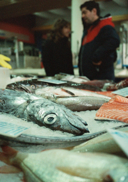

In [2]:
from PIL import Image
new_size = (128, 256)

img = Image.open(sample_path)
img.thumbnail(new_size) # Image.thumbnail keeps the aspect ratio, as opposed to Image.resize
display(img)

But choosing a non-default algorithm can make a difference. Most notably the nearest neighbor method that introdes more noise. This might be desired in this context.

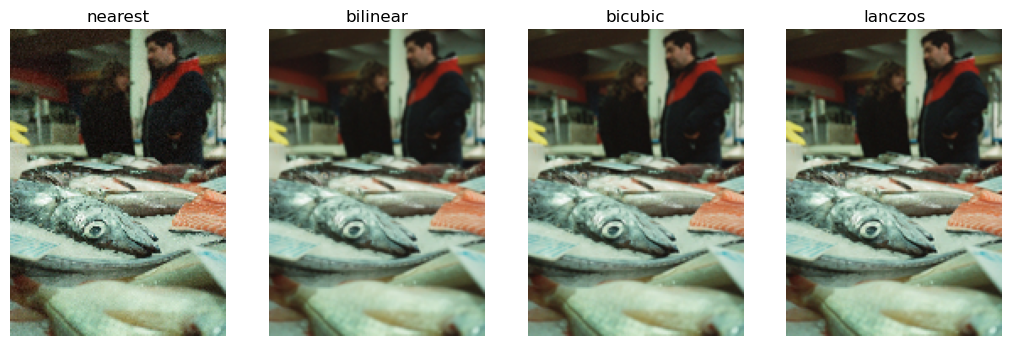

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def image_row(images, size=4):
    fig, axs = plt.subplots(1, len(images), figsize=(size*len(images)*0.8, size), squeeze=False)
    for ax, (key, img) in zip(axs[0], images.items()):
        ax.imshow(np.asarray(img))
        ax.set_title(str(key))
        ax.axis('off')
    return fig, axs

algorithms = {'nearest':Image.NEAREST, 'bilinear':Image.BILINEAR,'bicubic':Image.BICUBIC, 'lanczos':Image.LANCZOS}
downsized_images = dict()
for key, algorithm in algorithms.items():
    img = Image.open(sample_path)
    img.thumbnail(new_size, algorithm)
    downsized_images[key] = img

fig, axs = image_row(downsized_images)
plt.show()

Upscaling is done with the `BOX` algorithm, making each pixel bigger without introducing blur.

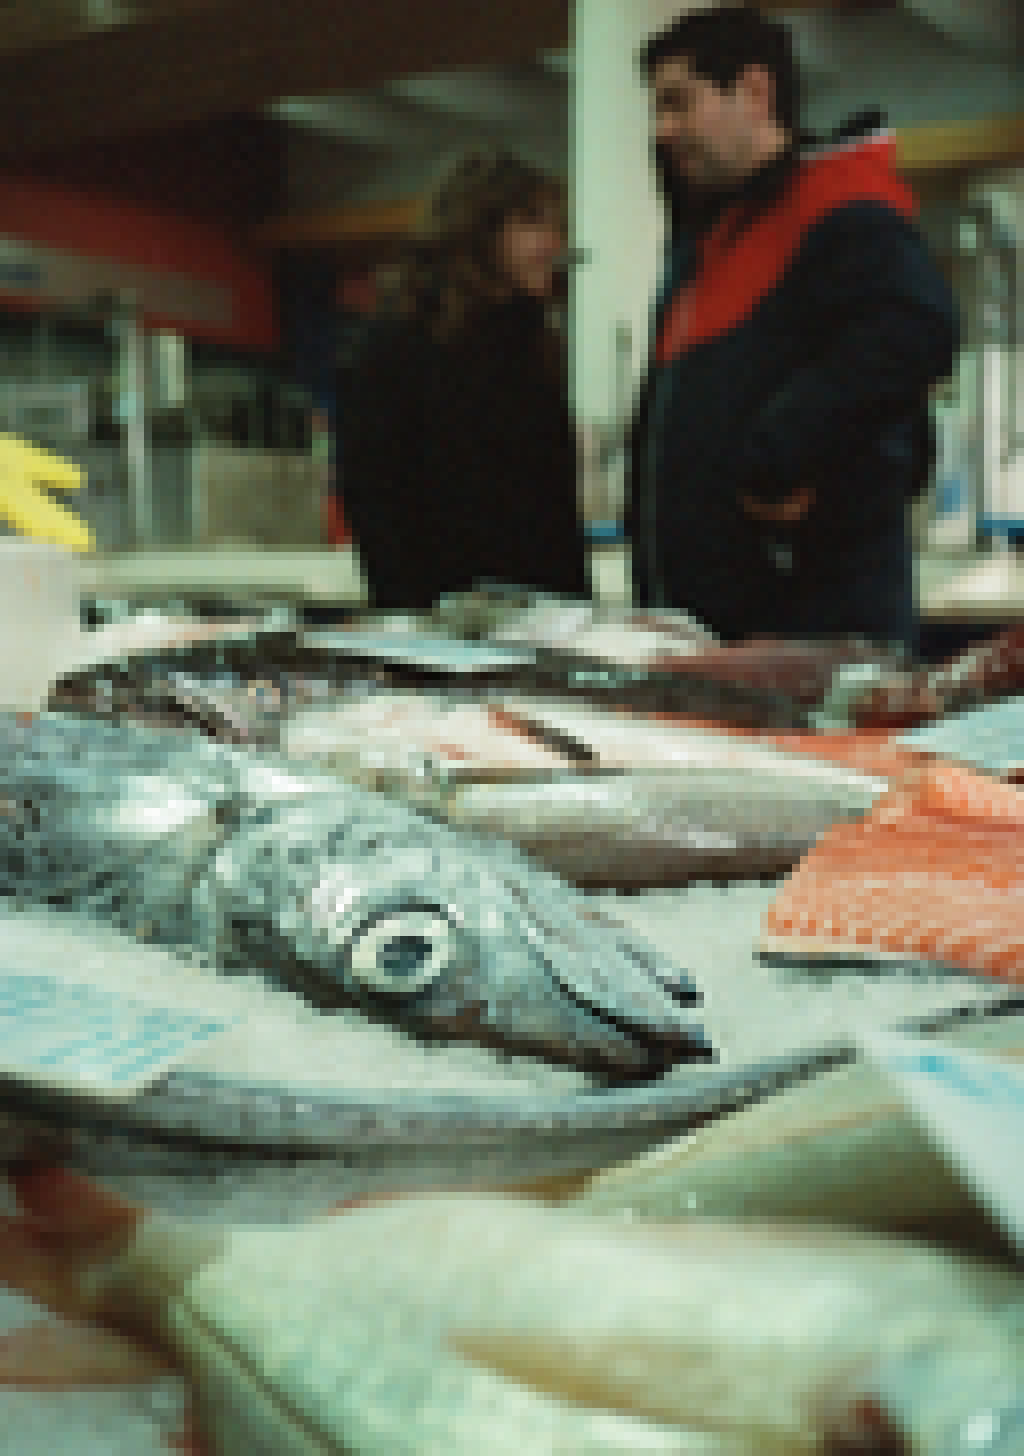

In [4]:
scaling = 8
d = img.resize(tuple(x * scaling for x in img.size), resample=Image.BOX)
display(d)

## Color space modification

A lot of the lofi appearance in the images Pixless produces is achieved by reducing the color space of the image, or rather by imposing a carefully curated color palette. I was able to color pick some of the projects palettes from [an image on the project website](https://static.wixstatic.com/media/90f783_75d4427dddd749d69232bcd5df33371e~mv2.jpg/v1/fill/w_564,h_956,al_c,q_85,usm_0.66_1.00_0.01,enc_avif,quality_auto/IMG_1108_edited.jpg). While a high quality jpeg can have several million unique colors, The lofi color palette has roughly eight.

In [5]:
im = Image.open(sample_path).convert("RGB")
print(f"Unique colors in original:  {len(np.unique(np.array(im).reshape(-1, 3), axis=0))}")

Unique colors in original:  166106


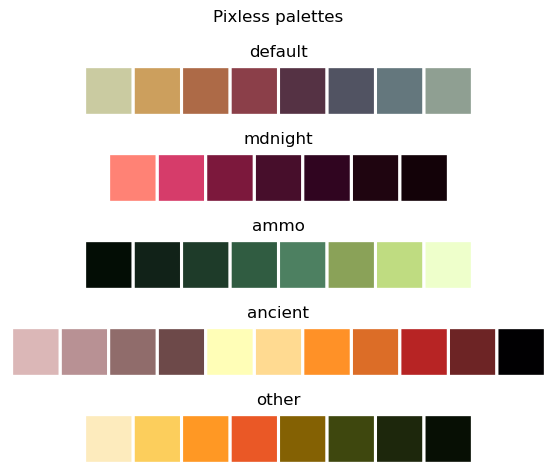

In [6]:
# https://www.pixlesscamera.com/pixless-camera-mk1
pixless_default = [(202, 203, 161), (204, 159, 93), (173, 106, 71) , (139, 63, 73), (85, 50, 68), (81, 83, 98), (100, 119, 125), (143, 159, 146)]
pixless_mdnight = [(255, 130, 117), (214, 60, 106), (124, 24, 60), (71, 14, 43), (48, 5, 32), (31, 5, 16), (19, 2, 8)]
pixless_ammo = [(3, 13, 5), (17, 34, 24), (30, 59, 41), (48, 92, 65), (77, 128, 97), (138, 162, 88), (191, 220, 129), (238, 255, 203)]
pixless_ancient = [(219, 183, 183), (184, 145, 148), (144, 108, 107), (109, 73, 73), (255, 254, 183), (255, 218, 145), (255, 145, 39), (220, 109, 39), (183, 36, 36), (109, 36, 37), (1, 0, 2)]
pixless_other = [(253, 235, 189), (252, 206, 92), (255, 152, 36), (234, 88, 38), (132, 97, 3), (62, 71, 14), (29, 39, 12), (7, 15, 4)]

palettes = {
    'default' : pixless_default,
    'mdnight' : pixless_mdnight,
    'ammo'    : pixless_ammo,
    'ancient' : pixless_ancient,
    'other'   : pixless_other
}

def palette_row(colors, swatch_size=42, padding=3, background=(255,255,255)):
    color_list: list[RGB] = [tuple(map(int, c))[:3] for c in colors]
    cols = len(color_list)
    width = cols * swatch_size + (cols + 1) * padding
    height = swatch_size + 2 * padding
    
    img = Image.new("RGB", (width, height), background)
    for i, color in enumerate(color_list):
        x = padding + i * (swatch_size + padding)
        y = padding
        img.paste(color, (x, y, x + swatch_size, y + swatch_size))
    return img

    
fig, axs = plt.subplots(len(palettes), 1)
for ax, key in zip(axs, palettes.keys()):
    palette = palettes[key]
    ax.imshow(palette_row(palette))
    ax.set_title(key)
    ax.axis("off")
fig.suptitle('Pixless palettes')
plt.tight_layout()

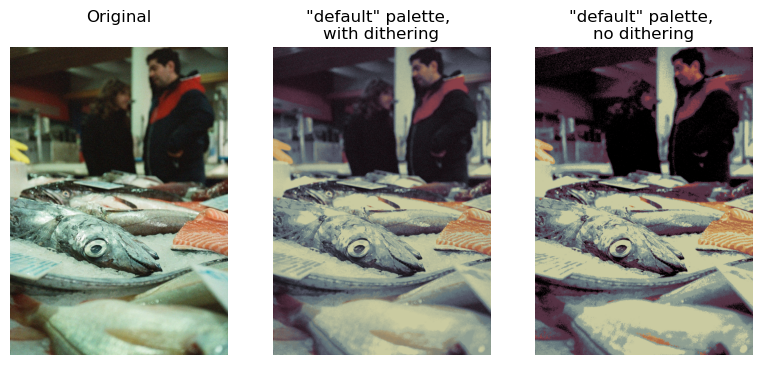

In [7]:
def build_palette_img(colors):
    # Build a P-mode "palette image" Pillow can use
    pal_img = Image.new("P", (1,1))
    flat = [v for rgb in colors for v in rgb]
    flat += [0] * (256*3 - len(flat))  # pad to 256*3 entries
    pal_img.putpalette(flat)
    return pal_img

palette_name = 'default'
palette_colors = palettes[palette_name]
pal_img = build_palette_img(palette_colors)

images = {"Original\n":im,
         f'"{palette_name}" palette, \nwith dithering':im.quantize(palette=pal_img, dither=Image.FLOYDSTEINBERG).convert("RGB"),
         f'"{palette_name}" palette, \nno dithering':im.quantize(palette=pal_img, dither=Image.NONE).convert("RGB")}

fig, axs = image_row(images)
plt.show()

The pixless project has *dithering* as a continuous parameter that can be set. To achieve this we can produce a dithered and a non-dithered (*flat*) image and blend them together with a conituous weight parameter.

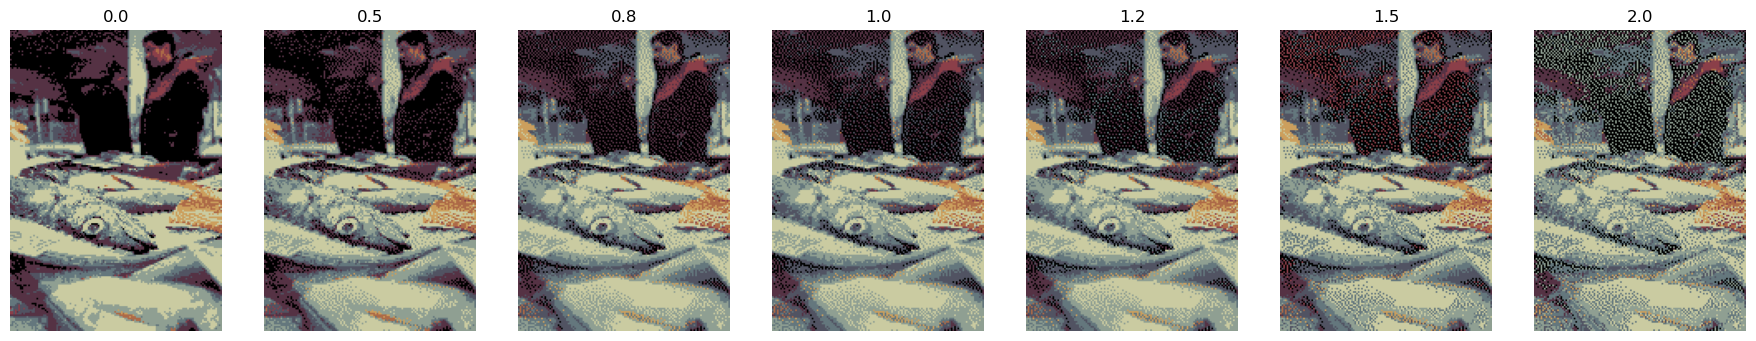

In [8]:
def simple_variable_dither_pil(rgb_image, pal_image, strength=0.75):
    dith = rgb_image.quantize(palette=pal_image, dither=Image.Dither.FLOYDSTEINBERG)
    flat = rgb_image.quantize(palette=pal_image, dither=Image.Dither.NONE)
    blended = Image.blend(flat.convert("RGB"), dith.convert("RGB"), strength)
    return blended.quantize(palette=pal_image, dither=Image.Dither.NONE).convert("RGB")

img = Image.open(sample_path)
img.thumbnail(new_size, Image.NEAREST)

images = dict()
for value in [0.0, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0]:
    image = simple_variable_dither_pil(img, pal_img, value)
    images[str(value)] = image

fig, axs = image_row(images)
plt.show()

# *Crominance*
The pixless website shows *crominance* as an adjustable parameter in a screenshot of the settings interface. Digital images sometimes seperate the color information from the information of luminence. This is called crominance. The crominance parameter thus most likely is a color saturation parameter. This can be achieved via `PIL.ImageEnhance`.

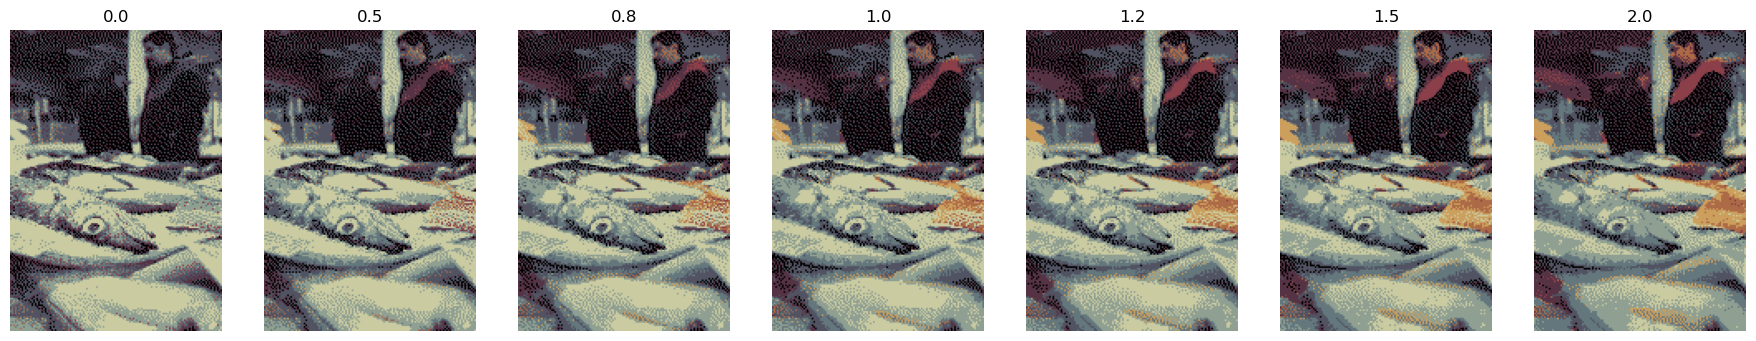

In [9]:
from PIL import ImageEnhance

img = Image.open(sample_path)
img.thumbnail(new_size, Image.NEAREST)

images = dict()
for value in [0.0, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0]:
    enhancer = ImageEnhance.Color(img)
    images[str(value)] = enhancer.enhance(value).quantize(palette=pal_img, dither=Image.FLOYDSTEINBERG).convert("RGB")

fig, axs = image_row(images)
plt.show()

# Batch processing

In [10]:
import os

def process_image(file_path, palette_name='default', new_size=(128,256)):
    palette_colors = palettes[palette_name]
    img = Image.open(file_path)
    img.thumbnail(new_size, Image.NEAREST)
    img = ImageEnhance.Color(img).enhance(1.5)
    img = img.quantize(palette=build_palette_img(palettes[palette_name]), dither=Image.FLOYDSTEINBERG).convert("RGB")
    img = img.resize(tuple(x * 4 for x in img.size), resample=Image.BOX)
    return img

file_list = sorted([os.path.join(dir_path,f) for f in os.listdir(dir_path) if f.endswith('.jpg')])
images = dict()

for path in file_list:
    img = process_image(path)
    images[path] = img
    output_dir = os.path.join(dir_path, 'output')
    os.makedirs(output_dir, exist_ok=True)
    write_path = os.path.join(output_dir, os.path.basename(path))
    img.save(write_path)

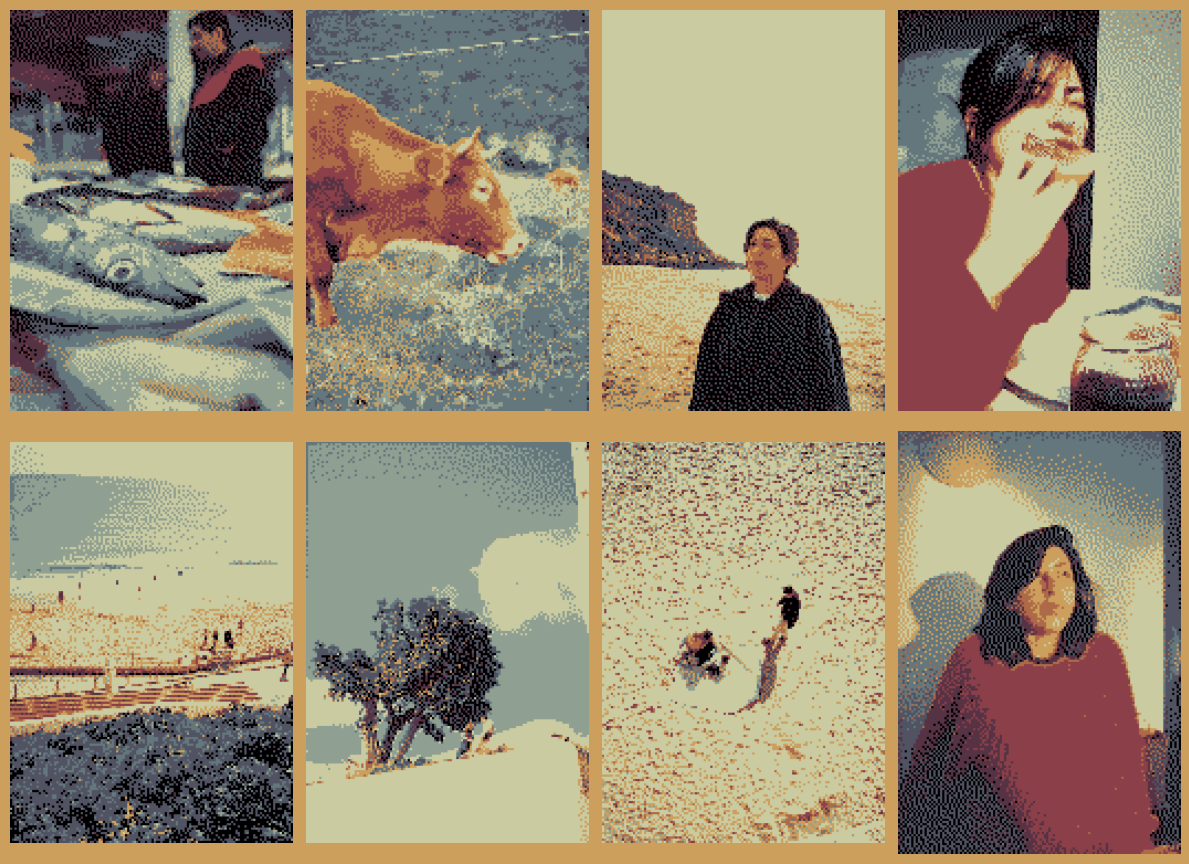

In [11]:
fig, axs = plt.subplots(2, 4, figsize=(12,9), facecolor=tuple(c/255 for c in palettes['default'][1]))
for ax, (key, img) in zip(np.ravel(axs), images.items()):
    ax.imshow(np.asarray(img))
    ax.axis('off')

plt.tight_layout(h_pad=1, w_pad=1)
plt.show()

# More fun with palettes

Previously we rudely and brutishly slapped a pre-made color scale on our image. But we can also derive our color scale from the image itself. Pillow provides the `quantize` method with three different quantisation algorithms. The visual effect of the different algorithms is clearly visible.

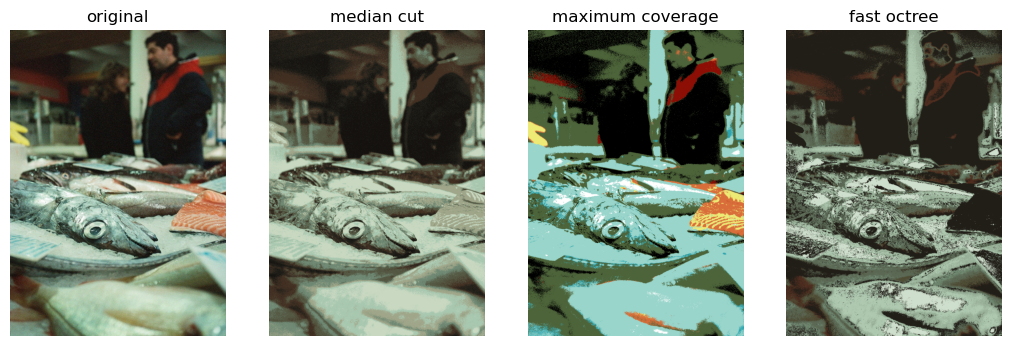

In [12]:
colors = 8
methods = {'median cut':Image.MEDIANCUT, 'maximum coverage':Image.MAXCOVERAGE, 'fast octree':Image.FASTOCTREE}
images = {'original'    : im}
for key, method in methods.items():
    images[key] = im.quantize(colors=colors, method=method).convert("RGB")
fig, axs = image_row(images)
plt.show()

Some of these difference are also visible in the resulting palettes.

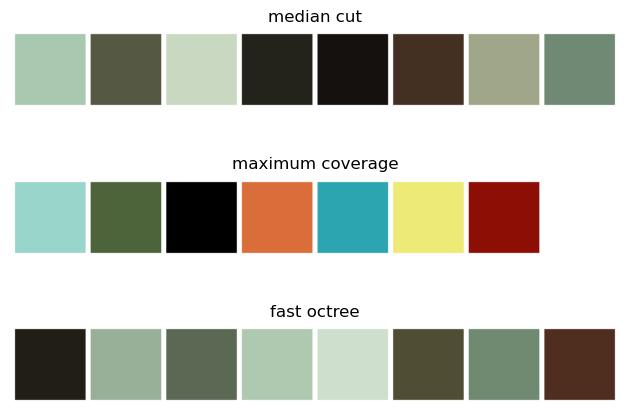

In [13]:
def extract_palette(image, n=8):
    counts = image.quantize(colors=n, method=Image.MEDIANCUT).getcolors(maxcolors=256)
    counts = sorted(counts, reverse=True) # most frequent first
    colors = [tuple(image.quantize(colors=n, method=Image.MEDIANCUT).getpalette()[3*i:3*i+3]) for _, i in counts]  # list of (R,G,B), len ≤ 16
    return colors

palettes = dict()
for key, img in images.items():
    if not key == 'original': palettes[key] = extract_palette(img)

fig, axs = plt.subplots(len(palettes), 1)
for ax, key in zip(axs, palettes.keys()):
    palette = palettes[key]
    ax.imshow(palette_row(palette))
    ax.set_title(key)
    ax.axis("off")
plt.tight_layout()

There are other ways of extracting a palette from an image. [Pylette](https://github.com/qTipTip/Pylette) uses a K-means based method. Since pip failed to install this package, here follows a dump of code to make Pylette available in this notebook.

In [14]:
# src/types.py
"""
Centralized type definitions for Pylette.

This module contains all the type aliases and protocols used throughout the Pylette library
to ensure type safety and consistency.
"""

from dataclasses import dataclass
from enum import Enum
from pathlib import Path
from typing import TYPE_CHECKING, Any, Protocol, TypeAlias, TypedDict

import numpy as np
from cv2.typing import MatLike
from numpy.typing import NDArray
from PIL import Image

if TYPE_CHECKING:
    from Pylette.src.palette import Palette

class ImageLike(Protocol):
    """Protocol for image-like objects that can be converted to PIL Image."""

    pass


class ArrayLike(Protocol):
    """Protocol for array-like objects."""

    def __array__(self) -> NDArray[np.uint8]: ...


# Specific image input types
PathLikeImage: TypeAlias = str | Path
URLImage: TypeAlias = str  # URLs are strings but semantically different
BytesImage: TypeAlias = bytes
ArrayImage: TypeAlias = NDArray[np.uint8]  # Properly typed array
CV2Image: TypeAlias = MatLike
PILImage: TypeAlias = Image.Image

# Main union type - more restrictive and logical
ImageInput: TypeAlias = PathLikeImage | URLImage | BytesImage | ArrayImage | PILImage | CV2Image

# Color array types
ColorArray: TypeAlias = NDArray[np.uint8]  # For RGB/RGBA color data
FloatArray: TypeAlias = NDArray[np.floating[Any]]  # For calculations
IntArray: TypeAlias = NDArray[np.integer[Any]]  # For integer arrays

# Color tuple types
RGBTuple: TypeAlias = tuple[int, int, int]
RGBATuple: TypeAlias = tuple[int, int, int, int]
ColorTuple: TypeAlias = RGBTuple | RGBATuple


class ExtractionMethod(str, Enum):
    MC = "MedianCut"
    KM = "KMeans"


class ColorSpace(str, Enum):
    RGB = "rgb"
    HSV = "hsv"
    HLS = "hls"


# PaletteMetaData Types
class SourceType(str, Enum):
    FILE_PATH = "file_path"
    URL = "url"
    BYTES = "bytes"
    PIL_IMAGE = "pil_image"
    NUMPY_ARRAY = "numpy_array"
    CV2_IMAGE = "cv2_image"
    UNKNOWN = "unknown"


class ExtractionParams(TypedDict):
    palette_size: int
    mode: ExtractionMethod
    sort_mode: str | None
    resize: bool
    alpha_mask_threshold: int | None


class ImageInfo(TypedDict):
    original_size: tuple[int, int]
    processed_size: tuple[int, int]
    format: str | None
    mode: str
    has_alpha: bool


class ProcessingStats(TypedDict):
    total_pixels: int
    valid_pixels: int
    extraction_time: float | None
    timestamp: str


class PaletteMetaData(TypedDict):
    image_source: str
    source_type: SourceType
    extraction_params: ExtractionParams
    image_info: ImageInfo
    processing_stats: ProcessingStats


# Batch extraction types
@dataclass
class BatchResult:
    source: ImageInput
    result: "Palette | None" = None
    exception: Exception | None = None

    @property
    def success(self) -> bool:
        return self.result is not None

    @property
    def palette(self) -> "Palette | None":
        return self.result

    @property
    def error(self) -> "Exception | None":
        return self.exception

In [15]:
# src/colors.py
import colorsys
from typing import cast
import numpy as np
# omitted because of single file structure
# from Pylette.src.types import ColorSpace

# Weights for calculating luminance
luminance_weights = np.array([0.2126, 0.7152, 0.0722])

class Color(object):
    def __init__(self, rgba: tuple[int, ...], frequency: float):
        """
        Initializes a Color object with RGBA values and frequency.

        Parameters:
            rgba (tuple[int, ...]): A tuple of RGBA values.
            frequency (float): The frequency of the color.
        """
        assert len(rgba) == 4, "RGBA values must be a tuple of length 4"
        *rgb, alpha = rgba
        self.rgb = cast(tuple[int, int, int], rgb)
        self.rgba = rgba
        self.a = alpha
        self.freq: float = frequency
        self.weight = alpha / 255.0

    def display(self, w: int = 50, h: int = 50) -> None:
        """
        Displays the color in a window of specified width and height.

        Parameters:
        w (int): Width of the window in pixels.
        h (int): Height of the window in pixels.
        """

        from PIL import Image

        img = Image.new("RGBA", size=(w, h), color=self.rgba)
        img.show()

    def __lt__(self, other: "Color") -> bool:
        """
        Compares the frequency of this color with another color.

        Parameters:
            other (Color): The other Color object to compare with.

        Returns:
            bool: True if the frequency of this color is less than the frequency of the other color, False otherwise.
        """
        return self.freq < other.freq

    def get_colors(self, colorspace: ColorSpace = ColorSpace.RGB) -> tuple[int, ...] | tuple[float, ...]:
        """
        Returns the color values in the specified color space.

        Parameters:
            colorspace (ColorSpace): The color space to use.

        Returns:
            tuple[int, ...] | tuple[float, ...]: The color values in the specified color space.
        """
        colors = {ColorSpace.RGB: self.rgb, ColorSpace.HSV: self.hsv, ColorSpace.HLS: self.hls}
        return colors[colorspace]

    @property
    def hsv(self) -> tuple[float, float, float]:
        """
        Converts the RGB color to HSV color space.

        Returns:
            tuple[float, float, float]: The color values in HSV color space.
        """
        return colorsys.rgb_to_hsv(r=self.rgb[0] / 255, g=self.rgb[1] / 255, b=self.rgb[2] / 255)

    @property
    def hls(self) -> tuple[float, float, float]:
        """
        Converts the RGB color to HLS color space.

        Returns:
            tuple[float, float, float]: The color values in HLS color space.
        """
        return colorsys.rgb_to_hls(r=self.rgb[0] / 255, g=self.rgb[1] / 255, b=self.rgb[2] / 255)

    @property
    def hex(self) -> str:
        """
        Returns the color as a hexadecimal string.

        Returns:
            str: The color in hexadecimal format (e.g., "#FF5733").
        """
        return f"#{self.rgb[0]:02X}{self.rgb[1]:02X}{self.rgb[2]:02X}"

    @property
    def luminance(self) -> float:
        """
        Calculates the luminance of the color.

        Returns:
        float: The luminance of the color.
        """
        return np.dot(luminance_weights, self.rgb)

In [16]:
# src/palette.py
import json
import numpy as np
from PIL import Image
# omitted because of single file structure
# from Pylette.src.color import Color
# from Pylette.src.types import ColorSpace, ExtractionParams, ImageInfo, PaletteMetaData, ProcessingStats, SourceType

class Palette:
    def __init__(self, colors: list[Color], metadata: PaletteMetaData | None = None):
        """
        Initializes a color palette with a list of Color objects.

        Parameters:
            colors (list[Color]): A list of Color objects.
        """

        self.colors = colors
        self.frequencies = [c.freq for c in colors]
        self.number_of_colors = len(colors)
        self.metadata = metadata

    def _generate_palette_image(self, w: int = 50, h: int = 50) -> Image.Image:
        """
        Helper method to generate a palette image.

        Parameters:
            w (int): Width of each color component.
            h (int): Height of each color component.

        Returns:
            PIL.Image.Image: The generated palette image.
        """
        img = Image.new("RGB", size=(w * self.number_of_colors, h))
        arr = np.asarray(img).copy()
        for i in range(self.number_of_colors):
            c = self.colors[i]
            arr[:, i * h : (i + 1) * h, :] = c.rgb
        return Image.fromarray(arr, "RGB")

    def save(
        self,
        w: int = 50,
        h: int = 50,
        filename: str = "color_palette",
        extension: str = "jpg",
    ) -> None:
        """
        Saves the color palette as an image.

        Parameters:
            w (int): Width of each color component.
            h (int): Height of each color component.
            filename (str): Filename.
            extension (str): File extension.
        """
        img = self._generate_palette_image(w, h)
        img.save(f"{filename}.{extension}")

    def display(
        self,
        w: int = 50,
        h: int = 50,
        save_to_file: bool = False,
        filename: str = "color_palette",
        extension: str = "jpg",
    ) -> None:
        """
        Displays the color palette as an image, with an option for saving the image.

        Parameters:
            w (int): Width of each color component.
            h (int): Height of each color component.
            save_to_file (bool): Whether to save the file or not.
            filename (str): Filename.
            extension (str): File extension.
        """
        img = self._generate_palette_image(w, h)
        img.show()

        if save_to_file:
            self.save(w, h, filename, extension)

    def __getitem__(self, item: int) -> Color:
        return self.colors[item]

    def __len__(self) -> int:
        return self.number_of_colors

    def random_color(self, N: int, mode: str = "frequency") -> list[Color]:
        """
        Returns N random colors from the palette, either using the frequency of each color, or choosing uniformly.

        Parameters:
            N (int): Number of random colors to return.
            mode (str): Mode to use for selection. Can be "frequency" or "uniform".

        Returns:
            list[Color]: List of N random colors from the palette.
        """

        if mode == "frequency":
            # Convert to numpy-compatible format for weighted selection
            colors_array = np.array(range(len(self.colors)))
            indices = np.random.choice(colors_array, size=N, p=self.frequencies)
            return [self.colors[i] for i in indices]
        elif mode == "uniform":
            # Uniform selection without weights
            colors_array = np.array(range(len(self.colors)))
            indices = np.random.choice(colors_array, size=N)
            return [self.colors[i] for i in indices]
        else:
            raise ValueError(f"Invalid mode: {mode}. Must be 'frequency' or 'uniform'.")

    def to_json(
        self,
        filename: str | None = None,
        colorspace: ColorSpace = ColorSpace.RGB,
        include_metadata: bool = True,
    ) -> dict[str, object] | None:
        """
        Exports the palette to JSON format.

        Parameters:
            filename (str | None): File to save to. If None, returns the dictionary.
            colorspace (Literal["rgb", "hsv", "hls"]): Color space to use.
            include_metadata (bool): Whether to include palette metadata.

        Returns:
            dict | None: The palette data as a dictionary if filename is None.
        """

        # Build the palette data
        palette_data: dict[str, object] = {
            "colors": [],
            "palette_size": self.number_of_colors,
            "colorspace": colorspace,
        }

        colors_list = []
        # Add color data
        for color in self.colors:
            color_values = color.get_colors(colorspace)
            color_data: dict[str, object] = {
                "frequency": float(color.freq),
            }

            # Add colorspace-specific field
            colorspace_field = colorspace.value.lower()  # "rgb", "hsv", "hls"
            if colorspace == ColorSpace.RGB:
                # RGB values should be integers
                color_data[colorspace_field] = [int(v) if isinstance(v, np.integer) else v for v in color_values]
            else:
                # HSV/HLS values should be floats
                color_data[colorspace_field] = [
                    float(v) if isinstance(v, (np.integer, np.floating)) else v for v in color_values
                ]

            # Add hex (always present, derived from RGB)
            color_data["hex"] = color.hex

            # Add RGB reference if colorspace is not RGB
            if colorspace != ColorSpace.RGB:
                color_data["rgb"] = [int(v) if isinstance(v, np.integer) else v for v in color.rgb]

            colors_list.append(color_data)

        palette_data["colors"] = colors_list

        # Add metadata if requested and available
        if include_metadata and self.metadata:
            metadata_dict: dict[str, object] = {}

            if "image_source" in self.metadata:
                metadata_dict["image_source"] = self.metadata["image_source"]
            if "source_type" in self.metadata:
                metadata_dict["source_type"] = self.metadata["source_type"]
            if "extraction_params" in self.metadata:
                metadata_dict["extraction_params"] = self.metadata["extraction_params"]
            if "image_info" in self.metadata:
                metadata_dict["image_info"] = self.metadata["image_info"]
            if "processing_stats" in self.metadata:
                metadata_dict["processing_stats"] = self.metadata["processing_stats"]

            palette_data["metadata"] = metadata_dict

        # Save to file if filename provided
        if filename is not None:
            with open(filename, "w") as f:
                json.dump(palette_data, f, indent=2)
            return None

        # Return data if no filename provided
        return palette_data

    def export(
        self,
        filename: str,
        colorspace: ColorSpace = ColorSpace.RGB,
        include_metadata: bool = True,
    ) -> None:
        """
        Export palette to JSON format.

        Parameters:
            filename (str): File to save to (extension will be added automatically if not present).
            colorspace (ColorSpace): Color space to use.
            include_metadata (bool): Whether to include metadata.
        """

        # Add .json extension if not present
        if not filename.endswith(".json"):
            filename = f"{filename}.json"

        self.to_json(filename=filename, colorspace=colorspace, include_metadata=include_metadata)

    def __str__(self):
        return "".join(["({}, {}, {}, {}) \n".format(c.rgb[0], c.rgb[1], c.rgb[2], c.freq) for c in self.colors])

    # Convenient metadata accessors
    @property
    def image_source(self) -> str | None:
        """Get the image source from metadata."""
        return self.metadata.get("image_source") if self.metadata else None

    @property
    def source_type(self) -> SourceType | None:
        """Get the source type from metadata."""
        return self.metadata.get("source_type") if self.metadata else None

    @property
    def extraction_params(self) -> ExtractionParams | None:
        """Get the extraction parameters from metadata."""
        return self.metadata.get("extraction_params") if self.metadata else None

    @property
    def image_info(self) -> ImageInfo | None:
        """Get the image information from metadata."""
        return self.metadata.get("image_info") if self.metadata else None

    @property
    def processing_stats(self) -> ProcessingStats | None:
        """Get the processing statistics from metadata."""
        return self.metadata.get("processing_stats") if self.metadata else None

In [17]:
# src/extractors/protocol.py
from abc import ABC, abstractmethod
from typing import Protocol, TypeVar
import numpy as np
from numpy.typing import NDArray
# omitted because of single file structure
# from Pylette.src.color import Color

NP_T = TypeVar("NP_T", bound=np.generic, covariant=True)

class ColorExtractor(Protocol):
    def extract(self, arr: NDArray[NP_T], height: int, width: int, palette_size: int) -> list[Color]: ...

class ColorExtractorBase(ABC):
    @abstractmethod
    def extract(self, arr: NDArray[NP_T], height: int, width: int, palette_size: int) -> list[Color]:
        pass

    def _reshape_array(self, arr: NDArray[NP_T], height: int, width: int) -> NDArray[NP_T]:
        return arr.reshape((height * width, -1))

In [18]:
# src/extractors/median_cut.py
import numpy as np
from numpy.typing import ArrayLike, NDArray
from typing_extensions import override
# omitted because of single file structure
# from Pylette.src.extractors.protocol import NP_T, ColorExtractorBase
# from Pylette.src.types import ColorArray

class ColorBox:
    """
    Represents a box in the RGBA color space, with associated attributes, used in the Median Cut algorithm.
    """

    def __init__(self, colors: ArrayLike):
        """
        Initializes a ColorBox with a numpy array of RGBA colors.

        Parameters:
            colors (ArrayLike): A numpy array of RGBA colors with shape (width * height, 4).
        """
        self.colors = np.asarray(colors, dtype=np.uint8)
        if self.colors.ndim < 2 or self.colors.shape[-1] != 4:
            raise ValueError("Invalid color array")
        self.alpha = self.colors[:, 3:4]
        self._get_min_max()

    def _get_min_max(self) -> None:
        """
        Calculates the minimum and maximum values for each color channel in the ColorBox.
        """
        self.min_channel: ColorArray = np.min(self.colors[:, :3], axis=0)
        self.max_channel: ColorArray = np.max(self.colors[:, :3], axis=0)

    def __lt__(self, other: "ColorBox") -> bool:
        """
        Compares two ColorBoxes based on their volume.

        Parameters:
            other (ColorBox): The other ColorBox to compare with.

        Returns:
        bool: True if the volume of this ColorBox is less than the volume of the other ColorBox, False otherwise.
        """
        return bool(self.size < other.size)

    @property
    def size(self) -> int:
        """
        Returns the volume of the ColorBox.

        Returns:
            np.uint64: The volume of the ColorBox.
        """
        return self.volume

    def _get_dominant_channel(self) -> int:
        """
        Determines the dominant color channel in the ColorBox.

        Returns:
            int: The index of the dominant color channel.
        """
        diff: ColorArray = self.max_channel - self.min_channel
        dominant_channel = np.argmax(diff)
        return int(dominant_channel)

    @property
    def average(self) -> ColorArray:
        """
        Calculates the average color contained in the ColorBox.

        Returns:
            np.ndarray: The average color as an array [R, G, B, A].
        """
        avg_rgb = np.mean(self.colors[:, :3], axis=0)
        avg_alpha = np.mean(self.alpha)
        if avg_rgb.shape != (3,):
            raise ValueError("Invalid number of channels in average color.")

        avg_color = np.append(avg_rgb, avg_alpha)
        return np.round(avg_color).astype(np.uint8)

    @property
    def volume(self) -> int:
        """
        Calculates the volume of the ColorBox.

        Returns:
            int: The volume of the ColorBox.
        """
        diff: ColorArray = self.max_channel - self.min_channel
        return np.prod(diff).item()

    def split(self) -> list["ColorBox"]:
        """
        Splits the ColorBox into two ColorBoxes at the median of the dominant color channel.

        Returns:
            list[ColorBox]: A list containing the two new ColorBoxes.
        """
        dominant_channel = self._get_dominant_channel()
        sort_indices = self.colors[:, dominant_channel].argsort()
        self.colors = self.colors[sort_indices]
        self.alpha = self.alpha[sort_indices]
        median_index = len(self.colors) // 2

        return [
            ColorBox(self.colors[:median_index]),
            ColorBox(self.colors[median_index:]),
        ]

    @property
    def pixel_count(self) -> int:
        """
        Returns the number of pixels in the ColorBox.

        Returns:
            int: The number of pixels in the ColorBox.
        """
        return len(self.colors)


class MedianCutExtractor(ColorExtractorBase):
    @override
    def extract(self, arr: NDArray[NP_T], height: int, width: int, palette_size: int) -> list[Color]:
        """
        Extracts a color palette using the median cut algorithm.

        Parameters:
            arr (np.ndarray): The input array.
            height (int): The height of the image.
            width (int): The width of the image.
            palette_size (int): The number of colors to extract from the image.

        Returns:
            list[Color]: A list of colors extracted from the image.
        """

        arr = self._reshape_array(arr=arr, height=height, width=width)
        valid_pixel_count = arr.shape[0]
        boxes = [ColorBox(arr)]
        while len(boxes) < palette_size:
            largest_box_idx = np.argmax([box.size for box in boxes])
            boxes = boxes[:largest_box_idx] + boxes[largest_box_idx].split() + boxes[largest_box_idx + 1 :]
        return [Color(tuple(map(int, box.average)), box.pixel_count / valid_pixel_count) for box in boxes]


def median_cut_extraction(arr: NDArray[NP_T], height: int, width: int, palette_size: int) -> list[Color]:
    """
    Extracts a color palette using the median cut algorithm.

    Parameters:
        arr (np.ndarray): The input array.
        height (int): The height of the image.
        width (int): The width of the image.
        palette_size (int): The number of colors to extract from the image.

    Returns:
        list[Color]: A list of colors extracted from the image.
    """

    return MedianCutExtractor().extract(arr, height, width, palette_size)

In [19]:
# src/extractors/k_means.py
import numpy as np
from numpy.typing import NDArray
from typing_extensions import override
# omitted because of single file structure
# from Pylette.src.color import Color
# from Pylette.src.extractors.protocol import NP_T, ColorExtractorBase

class KMeansExtractor(ColorExtractorBase):
    @override
    def extract(self, arr: NDArray[NP_T], height: int, width: int, palette_size: int) -> list[Color]:
        """
        Extracts a color palette using KMeans.

        Parameters:
            arr (NDArray[float]): The input array.
            height (int): The height of the image.
            width (int): The width of the image.
            palette_size (int): The number of colors to extract from the image.

        Returns:
            list[Color]: A palette of colors sorted by frequency.
        """

        from sklearn.cluster import KMeans

        arr = np.squeeze(arr)
        model = KMeans(n_clusters=palette_size, n_init="auto", init="k-means++", random_state=2024)
        labels = model.fit_predict(arr)
        palette = np.array(model.cluster_centers_, dtype=int)
        color_count = np.bincount(labels)
        color_frequency = color_count / float(np.sum(color_count))
        colors = []
        for color, freq in zip(palette, color_frequency):
            colors.append(Color(color, freq))
        return colors


def k_means_extraction(arr: NDArray[NP_T], height: int, width: int, palette_size: int) -> list[Color]:
    """
    Extracts a color palette using KMeans.

    Parameters:
        arr (NDArray[float]): The input array.
        height (int): The height of the image.
        width (int): The width of the image.
        palette_size (int): The number of colors to extract from the image.

    Returns:
        list[Color]: A palette of colors sorted by frequency.
    """
    return KMeansExtractor().extract(arr=arr, height=height, width=width, palette_size=palette_size)

In [20]:
# src/color_extraction.py
import time
import urllib.parse
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime
from io import BytesIO
from pathlib import Path
from typing import Callable, Literal, Sequence
import numpy as np
from PIL import Image
# omitted because of single file structure
# from Pylette.src.extractors.k_means import k_means_extraction
# from Pylette.src.extractors.median_cut import median_cut_extraction
# from Pylette.src.palette import Palette
# from Pylette.src.types import (
#     BatchResult,
#     ExtractionMethod,
#     ExtractionParams,
#     ImageInfo,
#     ImageInput,
#     PaletteMetaData,
#     PILImage,
#     ProcessingStats,
#     SourceType,
# )

def _is_url(image_str: str) -> bool:
    """Check if a string is a valid URL."""
    try:
        result = urllib.parse.urlparse(image_str)
        return all([result.scheme, result.netloc])
    except Exception:
        return False


def _normalize_image_input(image: ImageInput) -> PILImage:
    """Convert any valid image input to PIL Image."""
    if isinstance(image, Image.Image):
        return image
    elif isinstance(image, (str, Path)):
        image_str = str(image)
        if _is_url(image_str):
            return request_image(image_str)
        else:
            return Image.open(image)
    elif isinstance(image, bytes):
        return Image.open(BytesIO(image))
    elif hasattr(image, "__array__"):  # More general check for array-like objects
        return Image.fromarray(image)
    else:
        raise TypeError(f"Unsupported image type: {type(image)}")


def _get_source_type_from_image_input(image: ImageInput) -> SourceType:
    if isinstance(image, Image.Image):
        source_type = SourceType.PIL_IMAGE
    elif isinstance(image, (str, Path)):
        image_str = str(image)
        if _is_url(image_str):
            source_type = SourceType.URL
        else:
            source_type = SourceType.FILE_PATH
    elif isinstance(image, bytes):
        source_type = SourceType.BYTES
    elif hasattr(image, "__array__"):
        source_type = SourceType.NUMPY_ARRAY
    else:
        source_type = SourceType.UNKNOWN
    return source_type


def _get_descriptive_image_source(image: ImageInput, pil_image: PILImage) -> str:
    """Generate a descriptive image source string for metadata."""
    if isinstance(image, Image.Image):
        return f"<pil_image: {pil_image.size[0]}x{pil_image.size[1]} {pil_image.mode}>"
    elif isinstance(image, (str, Path)):
        return str(image)
    elif isinstance(image, bytes):
        return f"<bytes: {len(image):,} bytes>"
    elif hasattr(image, "__array__"):
        arr = np.asarray(image)
        return f"<numpy_array: shape={arr.shape}>"
    else:
        return f"<unknown: {type(image).__name__}>"


def batch_extract_colors(
    images: Sequence[ImageInput],
    palette_size: int = 5,
    resize: bool = True,
    mode: ExtractionMethod = ExtractionMethod.KM,
    sort_mode: Literal["luminance", "frequency"] | None = None,
    alpha_mask_threshold: int | None = None,
    max_workers: int | None = None,
    progress_callback: Callable[[int, BatchResult], None] | None = None,
) -> list[BatchResult]:
    """Extract colors from multiple images in parallel.

    Args:
        progress_callback: Optional callback function called when each task completes.
                         Receives (task_number, result) as arguments.
    """

    def thread_fn(image: ImageInput):
        return extract_colors(
            image=image,
            palette_size=palette_size,
            resize=resize,
            mode=mode,
            sort_mode=sort_mode,
            alpha_mask_threshold=alpha_mask_threshold,
        )

    results: list[BatchResult] = []
    task_number = 1

    with ThreadPoolExecutor(max_workers=max_workers, thread_name_prefix="pylette") as executor:
        futures_to_image_map = {executor.submit(thread_fn, image): image for image in images}

        for future in as_completed(futures_to_image_map):
            source_image = futures_to_image_map[future]
            try:
                r = future.result()
                batch_result = BatchResult(source=source_image, result=r)
                results.append(batch_result)
                if progress_callback:
                    progress_callback(task_number, batch_result)
            except Exception as e:
                batch_result = BatchResult(source=source_image, exception=e)
                results.append(batch_result)
                if progress_callback:
                    progress_callback(task_number, batch_result)
            task_number += 1

    # Return results in original order
    source_to_result = {r.source: r for r in results}
    return [source_to_result[source] for source in images]


def extract_colors(
    image: ImageInput,
    palette_size: int = 5,
    resize: bool = True,
    mode: ExtractionMethod = ExtractionMethod.KM,
    sort_mode: Literal["luminance", "frequency"] | None = None,
    alpha_mask_threshold: int | None = None,
) -> Palette:
    """
    Extracts a set of 'palette_size' colors from the given image.

    Parameters:
        image: The input image.
        palette_size: The number of colors to extract.
        resize: Whether to resize the image before processing.
        mode: The color quantization algorithm to use.
        sort_mode: The mode to sort colors.
        alpha_mask_threshold: Optional integer between 0, 255.
            Any pixel with alpha less than this threshold will be discarded from calculations.
    Returns:
        Palette: A palette of the extracted colors.

    Examples:
        Colors can be extracted from a variety of sources, including local files, byte streams, URLs, and numpy arrays.

        >>> extract_colors("path/to/image.jpg", palette_size=5, resize=True, mode="KM", sort_mode="luminance")
        >>> extract_colors(b"image_bytes", palette_size=5, resize=True, mode="KM", sort_mode="luminance")
    """

    start_time = time.time()

    source_type = _get_source_type_from_image_input(image)
    # Normalize input to PIL Image and convert to RGBA
    img_obj = _normalize_image_input(image)
    original_size = img_obj.size
    img = img_obj.convert("RGBA")

    # Store original image info
    image_info = ImageInfo(
        original_size=original_size,
        processed_size=img.size if not resize else (256, 256),
        format=getattr(img_obj, "format", None),
        mode=img.mode,
        has_alpha=img.mode in ("RGBA", "LA") or "transparency" in img_obj.info,
    )

    if resize:
        img = img.resize((256, 256))
        image_info["processed_size"] = (256, 256)

    width, height = img.size
    arr = np.asarray(img)

    if alpha_mask_threshold is None:
        alpha_mask_threshold = 0

    alpha_mask = arr[:, :, 3] <= alpha_mask_threshold
    valid_pixels = arr[~alpha_mask]

    if len(valid_pixels) == 0:
        raise ValueError(
            f"No valid pixels remain after applying alpha mask with threshold {alpha_mask_threshold}. "
            f"Try using a lower alpha-mask-threshold value or check if your image has transparency."
        )

    # Color extraction
    match mode:
        case ExtractionMethod.KM:
            colors = k_means_extraction(valid_pixels, height, width, palette_size)
        case ExtractionMethod.MC:
            colors = median_cut_extraction(valid_pixels, height, width, palette_size)

    if colors:
        if sort_mode == "luminance":
            colors.sort(key=lambda c: c.luminance, reverse=False)
        else:
            colors.sort(reverse=True)

    end_time = time.time()

    # Build comprehensive metadata
    metadata = PaletteMetaData(
        image_source=_get_descriptive_image_source(image, img_obj),
        source_type=source_type,
        extraction_params=ExtractionParams(
            palette_size=palette_size,
            mode=mode,
            sort_mode=sort_mode,
            resize=resize,
            alpha_mask_threshold=alpha_mask_threshold,
        ),
        image_info=image_info,
        processing_stats=ProcessingStats(
            total_pixels=width * height,
            valid_pixels=len(valid_pixels),
            extraction_time=end_time - start_time,
            timestamp=datetime.now().isoformat(),
        ),
    )

    return Palette(colors, metadata=metadata)

def request_image(image_url: str) -> Image.Image:
    """
    Requests an image from a given URL.

    Parameters:
        image_url (str): The URL of the image.

    Returns:
        Image.Image: The requested image.

    Raises:
        ValueError: If the URL does not point to a valid image.
    """
    import requests

    response = requests.get(image_url)
    # Check if the request was successful and content type is an image
    if response.status_code == 200 and "image" in response.headers.get("Content-Type", ""):
        img = Image.open(BytesIO(response.content))
        return img
    else:
        raise ValueError("The URL did not point to a valid image.")

In [21]:
palettes['pylette'] = [tuple(c.rgb) for c in extract_colors(img, 8).colors]

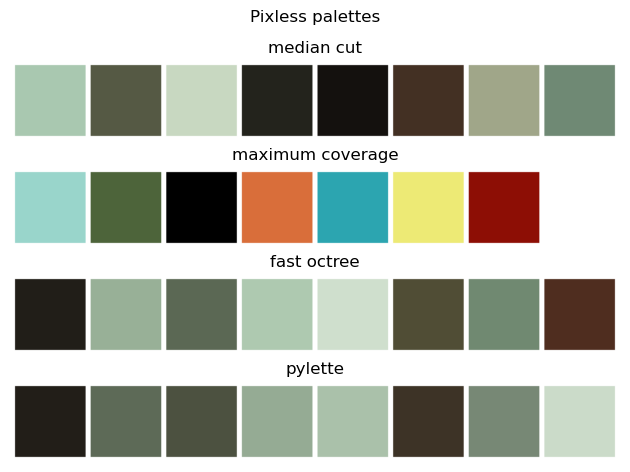

In [22]:
fig, axs = plt.subplots(len(palettes), 1)
for ax, key in zip(axs, palettes.keys()):
    palette = palettes[key]
    ax.imshow(palette_row(palette))
    ax.set_title(key)
    ax.axis("off")
fig.suptitle('Pixless palettes')
plt.tight_layout()

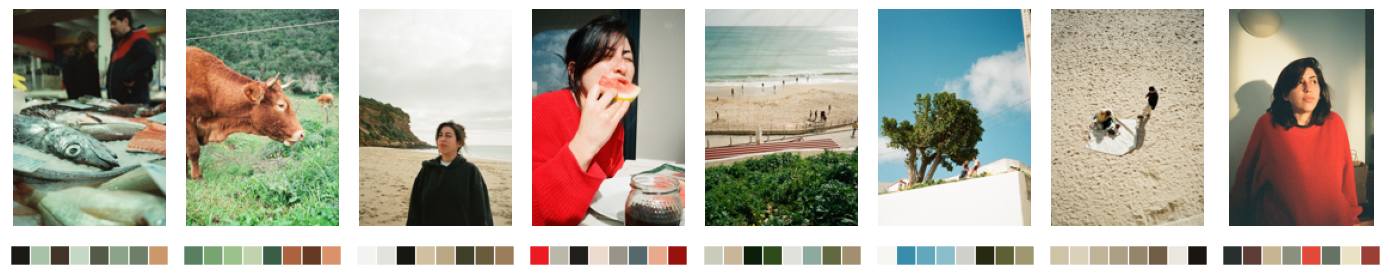

In [23]:
from matplotlib.gridspec import GridSpecFromSubplotSpec

def split_axes_image_palette(ax, palette_frac=0.18, gap=0.04):
    subplotspec = getattr(ax, "get_subplotspec", lambda: None)()
    fig = ax.figure
    gs = GridSpecFromSubplotSpec(
        2, 1,
        subplot_spec=subplotspec,
        height_ratios=[1 - palette_frac, palette_frac],
        hspace=gap
    )
    ax_img = fig.add_subplot(gs[0])
    ax_pal = fig.add_subplot(gs[1])
    fig.delaxes(ax)
        
    # Tidy defaults
    ax_img.set_xticks([])
    ax_img.set_yticks([])
    ax_pal.set_axis_off()
    for a in (ax_img, ax_pal):
        for spine in a.spines.values():
            spine.set_visible(False)

    return ax_img, ax_pal

images, palettes = dict(), dict()
for path in file_list:
    img = Image.open(path)
    key = os.path.basename(path)
    palettes[key] = [tuple(c.rgb) for c in extract_colors(img, 8).colors]
    img.thumbnail(new_size)
    images[key] = img

fig, axs = plt.subplots(1, len(palettes), figsize=(14,3))
for ax, key in zip(axs, palettes.keys()):
    img = images[key]
    palette = palettes[key]
    ax_img, ax_pal = split_axes_image_palette(ax)
    ax_img.imshow(img)
    ax_pal.imshow(palette_row(palette))
    # ax.set_title(key)
    ax.axis("off")
plt.tight_layout()

### OOP approach

made into a module with two classes.

In [24]:
from PIL import Image, ImageEnhance
import warnings
try:    import matplotlib
except: warnings.warn('matplotlib not available.')
    
__all__ = ['PixelfyOps', 'Pixelfy']

class PixelfyOps:
    """
    Stateless toolkit of image processing operations for the pixel art effect.

    All methods are static and can be used independently of the :class:`Pixelfy` workflow.
    Constants :attr:`PALETTES`, :attr:`DOWNSCALE_METHODS`, and :attr:`INFER_METHODS` are
    exposed for inspection and use by custom subclasses or external code.

    Example::

        from PIL import Image
        img = Image.open("photo.jpg")
        small = PixelfyOps.shrink(img, resolution=(64, 64))
        result = PixelfyOps.variable_dither(small, strength=0.5)
    """

    PALETTES = {
        # colorpicked from screenshot on https://www.pixlesscamera.com/pixless-camera-mk1
        'default' : [(202, 203, 161), (204, 159, 93), (173, 106, 71) , (139, 63, 73), (85, 50, 68), (81, 83, 98), (100, 119, 125), (143, 159, 146)],
        'mdnight' : [(255, 130, 117), (214, 60, 106), (124, 24, 60), (71, 14, 43), (48, 5, 32), (31, 5, 16), (19, 2, 8)],
        'ammo'    : [(3, 13, 5), (17, 34, 24), (30, 59, 41), (48, 92, 65), (77, 128, 97), (138, 162, 88), (191, 220, 129), (238, 255, 203)],
        'ancient' : [(219, 183, 183), (184, 145, 148), (144, 108, 107), (109, 73, 73), (255, 254, 183), (255, 218, 145), (255, 145, 39), (220, 109, 39), (183, 36, 36), (109, 36, 37), (1, 0, 2)],
        'other'   : [(253, 235, 189), (252, 206, 92), (255, 152, 36), (234, 88, 38), (132, 97, 3), (62, 71, 14), (29, 39, 12), (7, 15, 4)]
    }
    """Named palettes colorpicked from the Pixless Camera Mk1. Each entry is a list of RGB 3-tuples."""

    DOWNSCALE_METHODS = {'nearest':Image.NEAREST, 'bilinear':Image.BILINEAR,'bicubic':Image.BICUBIC, 'lanczos':Image.LANCZOS}
    """Mapping of algorithm name strings to PIL resampling filters used during downscaling."""

    INFER_METHODS = {'mediancut': Image.MEDIANCUT, 'maxcoverage': Image.MAXCOVERAGE, 'fastoctree': Image.FASTOCTREE}
    """Mapping of method name strings to PIL quantization methods used for palette inference."""

    @staticmethod
    def _validate_shrink_algorithm(value):
        """Validate that *value* is a key in :attr:`DOWNSCALE_METHODS`. Returns *value* unchanged."""
        valid = set(PixelfyOps.DOWNSCALE_METHODS.keys())
        if value not in valid:
            raise ValueError(f"shrink_algorithm must be one of {valid}, got '{value}'")
        return value

    @staticmethod
    def _validate_infer_method(value):
        """Validate that *value* is a key in :attr:`INFER_METHODS`. Returns *value* unchanged."""
        if value not in PixelfyOps.INFER_METHODS:
            raise ValueError(f"infer method must be one of {PixelfyOps.INFER_METHODS}, got '{value}'")
        return value

    @staticmethod
    def _validate_image(value):
        """Validate that *value* is a PIL :class:`Image.Image`. Returns *value* unchanged."""
        if not isinstance(value, Image.Image):
            raise TypeError(f"image must be a PIL Image, got {type(value).__name__}")
        return value

    @staticmethod
    def _validate_rgb(value):
        """
        Validate that *value* is a 3-tuple of ints each in the range 0–255.
        Returns *value* unchanged.
        """
        if not isinstance(value, tuple) or len(value) != 3:
            raise TypeError(f"RGB value must be a 3-tuple, got {value!r}")
        if not all(isinstance(v, int) and 0 <= v <= 255 for v in value):
            raise ValueError(f"RGB channels must be ints in 0–255, got {value!r}")
        return value

    @staticmethod
    def _validate_palette(value):
        """
        Validate a palette argument.

        *value* may be:

        - A ``str`` naming a key in :attr:`PALETTES` or :attr:`INFER_METHODS`.
        - A non-empty ``list`` of RGB 3-tuples, each validated by :meth:`_validate_rgb`.

        Returns *value* unchanged.
        """
        if isinstance(value, str):
            valid = set(PixelfyOps.PALETTES.keys()) | PixelfyOps.INFER_METHODS.keys()
            if value not in valid:
                raise ValueError(f"palette string must be one of {valid}, got '{value}'")
        elif isinstance(value, list):
            if len(value) == 0:
                raise ValueError("palette list must not be empty")
            for i, color in enumerate(value):
                try:
                    PixelfyOps._validate_rgb(color)
                except (TypeError, ValueError) as e:
                    raise type(e)(f"palette[{i}]: {e}") from e
        else:
            raise TypeError(f"palette must be a str or list of RGB tuples, got {type(value).__name__}")
        return value

    @staticmethod
    def _validate_saturation(value):
        """Validate that *value* is a non-negative number. Returns it as a ``float``."""
        if not isinstance(value, (int, float)):
            raise TypeError(f"saturation must be a number, got {type(value).__name__}")
        if value < 0:
            raise ValueError(f"saturation must be >= 0, got {value}")
        return float(value)

    @staticmethod
    def _validate_dithering(value):
        """Validate that *value* is a number in the range [0, 1]. Returns it as a ``float``."""
        if not isinstance(value, (int, float)):
            raise TypeError(f"dithering must be a number, got {type(value).__name__}")
        if not 0 <= value <= 1:
            raise ValueError(f"dithering must be between 0 and 1, got {value}")
        return float(value)

    @staticmethod
    def _validate_resolution(value):
        """Validate that *value* is a 2-tuple of positive ints. Returns *value* unchanged."""
        if (
            not isinstance(value, tuple) or len(value) != 2 or
            not all(isinstance(d, int) and d > 0 for d in value)
        ):
            raise ValueError(f"resolution must be a tuple of two positive ints, got {value!r}")
        return value

    @staticmethod
    def _validate_upscaling(value):
        """Validate that *value* is a positive int. Returns *value* unchanged."""
        if not isinstance(value, int) or value < 1:
            raise TypeError(f"upscaling must be a positive int, got {value!r}")
        return value

    @staticmethod
    def _palette_image2palette(image):
        """
        Extract the palette from a PIL palette-mode image as a list of RGB 3-tuples.

        :param image: A PIL image in ``'P'`` (palette) mode.
        :returns: List of 256 ``(R, G, B)`` tuples.
        """
        palette_data = image.getpalette()  # returns flat [R,G,B, R,G,B, ...] list of 256*3 values
        return [tuple(palette_data[i:i+3]) for i in range(0, len(palette_data), 3)]

    @staticmethod
    def infer_palette(image, ncolors=8, method='mediancut'):
        """
        Derive a palette from an image using PIL quantization.

        :param image: Source PIL image.
        :param ncolors: Number of colors to extract (default 8).
        :param method: Quantization method — one of ``'mediancut'``, ``'maxcoverage'``,
            ``'fastoctree'`` (default ``'mediancut'``).
        :returns: List of ``(R, G, B)`` tuples representing the inferred palette.
        """
        method = PixelfyOps._validate_infer_method(method)
        return PixelfyOps._palette_image2palette(image.quantize(colors=ncolors, method=PixelfyOps.INFER_METHODS[method]))

    @staticmethod
    def palette_from_hex_file(path):
        """
        Load a palette from a plain-text hex file, as provided by `Lospec <https://lospec.com/palette-list>`_.

        Each line of the file should contain exactly one 6-character hex color code (e.g. ``ff8800``),
        with no leading ``#``.

        :param path: Path to the ``.hex`` palette file.
        :returns: List of ``(R, G, B)`` tuples.
        """
        with open(path) as f:
            return [tuple(int(line.strip()[i:i+2], 16) for i in (0, 2, 4)) for line in f if line.strip()]

    @staticmethod
    def palette_from_mpl(cmap_name, n=8):
        """
        Sample a Matplotlib colormap as a palette.

        Samples *n* evenly spaced colors from the colormap identified by *cmap_name*.
        Requires ``matplotlib`` to be installed.

        :param cmap_name: Name of a Matplotlib colormap (e.g. ``'viridis'``, ``'plasma'``).
        :param n: Number of colors to sample (default 8).
        :returns: List of ``(R, G, B)`` tuples.
        :raises ImportError: If ``matplotlib`` is not installed.
        """
        try: import matplotlib
        except ImportError:
            raise ImportError("matplotlib is required for palette_from_mpl()") from None
        cmap = matplotlib.colormaps[cmap_name]
        return [tuple(int(v * 255) for v in cmap(i / (n - 1))[:3]) for i in range(n)]
            
    @staticmethod
    def build_palette_img(colors):
        """
        Build a PIL palette-mode image from a list of colors.

        Used internally to prepare a quantization target for PIL's ``quantize()``.
        The palette is padded to 256 entries with black if fewer colors are provided.

        :param colors: List of ``(R, G, B)`` tuples (up to 256).
        :returns: A 1×1 PIL image in ``'P'`` mode carrying the given palette.
        """
        pal_img = Image.new("P", (1, 1))
        flat = [v for rgb in colors for v in rgb]
        flat += [0] * (256 * 3 - len(flat))
        pal_img.putpalette(flat)
        return pal_img

    @staticmethod
    def shrink(image, resolution=(128, 256), algorithm='lanczos'):
        """
        Downscale an image to fit within *resolution*, preserving aspect ratio.

        Uses :meth:`Image.thumbnail` internally, so *resolution* is a bounding box,
        not an exact target size.

        :param image: Source PIL image.
        :param resolution: Maximum ``(width, height)`` bounding box (default ``(128, 256)``).
        :param algorithm: Resampling algorithm — one of ``'nearest'``, ``'bilinear'``,
            ``'bicubic'``, ``'lanczos'`` (default ``'lanczos'``).
        :returns: A downscaled copy of the image.
        """
        algorithm = PixelfyOps._validate_shrink_algorithm(algorithm)
        result = image.copy()
        result.thumbnail(resolution, PixelfyOps.DOWNSCALE_METHODS[algorithm])
        return result

    @staticmethod
    def adjust_saturation(image, value=1.0):
        """
        Adjust the color saturation of an image.

        :param image: Source PIL image.
        :param value: Saturation multiplier. ``0`` produces greyscale, ``1`` leaves the
            image unchanged, values above ``1`` oversaturate (default ``1.0``).
        :returns: Saturation-adjusted PIL image.
        """
        value = PixelfyOps._validate_saturation(value)
        enhancer = ImageEnhance.Color(image)
        return enhancer.enhance(value)
        
    @staticmethod
    def variable_dither(image, strength=0.75, palette=None):
        """
        Quantize an image to a palette with variable dithering strength.

        Blends a fully dithered (Floyd-Steinberg) quantization with a flat (no dither)
        quantization according to *strength*, then re-quantizes the blend. This allows
        fine-grained control between the structured look of flat quantization and the
        smoother gradients of full dithering.

        :param image: Source PIL image.
        :param strength: Dithering blend factor in [0, 1]. ``0`` = no dithering,
            ``1`` = full Floyd-Steinberg (default ``0.75``).
        :param palette: Target palette as a list of ``(R, G, B)`` tuples, or a palette
            name string. Defaults to :attr:`PixelfyOps.PALETTES['default'] <PALETTES>`.
        :returns: Quantized PIL image in ``'RGB'`` mode.
        """
        if palette is None: palette = PixelfyOps.PALETTES['default']
        palette = PixelfyOps._validate_palette(palette)
        strength = PixelfyOps._validate_dithering(strength)
        pal_image = PixelfyOps.build_palette_img(palette)
        dith = image.quantize(palette=pal_image, dither=Image.Dither.FLOYDSTEINBERG)
        flat = image.quantize(palette=pal_image, dither=Image.Dither.NONE)
        blended = Image.blend(flat.convert("RGB"), dith.convert("RGB"), strength)
        return blended.quantize(palette=pal_image, dither=Image.Dither.NONE).convert("RGB")

    @staticmethod
    def scale_up(image, scaling=8):
        """
        Upscale an image by an integer factor using nearest-neighbor (box) resampling.

        Nearest-neighbor is intentional here — it preserves the hard pixel edges
        characteristic of pixel art.

        :param image: Source PIL image.
        :param scaling: Integer scale factor (default ``8``).
        :returns: Upscaled PIL image.
        """
        scaling = PixelfyOps._validate_upscaling(scaling)
        return image.resize(tuple(x * scaling for x in image.size), resample=Image.BOX)

    @staticmethod
    def palette_visualisation(colors, swatch_size=42, padding=3, background=(255, 255, 255)):
        """
        Render a palette as a row of color swatches.
    
        :param colors: List of ``(R, G, B)`` tuples to display.
        :param swatch_size: Width and height of each color square in pixels (default ``42``).
        :param padding: Gap in pixels between swatches and around the image border (default ``3``).
        :param background: Background color as an ``(R, G, B)`` tuple (default white).
        :returns: PIL image containing the rendered palette.
        :raises TypeError: If any color or the background is not a valid RGB 3-tuple.
        :raises ValueError: If *colors* is empty or any channel value is out of range.
        """
        if not isinstance(swatch_size, int) or swatch_size < 1:
            raise ValueError(f"swatch_size must be a positive int, got {swatch_size!r}")
        if not isinstance(padding, int) or padding < 0:
            raise ValueError(f"padding must be a non-negative int, got {padding!r}")
    
        PixelfyOps._validate_rgb(background)
        color_list = []
        for i, c in enumerate(colors):
            try:
                PixelfyOps._validate_rgb(c)
            except (TypeError, ValueError) as e:
                raise type(e)(f"colors[{i}]: {e}") from e
            color_list.append(c)
        if not color_list: raise ValueError("colors must not be empty")
    
        cols = len(color_list)
        width = cols * swatch_size + (cols + 1) * padding
        height = swatch_size + 2 * padding
    
        img = Image.new("RGB", (width, height), background)
        for i, color in enumerate(color_list):
            x = padding + i * (swatch_size + padding)
            y = padding
            img.paste(color, (x, y, x + swatch_size, y + swatch_size))
        return img
        
        

class Pixelfy:
    """
    Applies a retro pixel art effect to a PIL Image.

    Bundles the stateless operations in :class:`PixelfyOps` into a configured,
    reusable workflow. Parameters are validated on construction and stored as
    instance attributes, then applied in sequence by :meth:`make`.

    A custom ops class can be injected via the *ops* parameter to override
    individual processing steps without subclassing :class:`Pixelfy` itself.

    This is heavily inspired by the `Pixless Camera project <https://www.pixlesscamera.com/>`_.

    Usage::

        from PIL import Image

        im = Image.open("photo.jpg")
        result = Pixelfy(im).make()
        result.save("out.jpg")
    """

    def __init__(self, 
                 image, 
                 palette='default', 
                 saturation=1.0, 
                 dithering=0.75,
                 resolution=(128, 256), 
                 shrink_algorithm='lanczos',
                 upscaling=8, 
                 ops=PixelfyOps):
        """
        :param image: Source PIL image to process.
        :param palette: Palette to quantize to. Either a name string from
            :attr:`PixelfyOps.PALETTES`, an infer method string from
            :attr:`PixelfyOps.INFER_METHODS`, or a list of ``(R, G, B)`` tuples
            (default ``'default'``).
        :param saturation: Saturation multiplier applied before quantization.
            ``0`` = greyscale, ``1`` = unchanged (default ``1.0``).
        :param dithering: Dithering blend strength in [0, 1]. ``0`` = flat quantization,
            ``1`` = full Floyd-Steinberg (default ``0.75``).
        :param resolution: Maximum ``(width, height)`` bounding box for downscaling
            (default ``(128, 256)``).
        :param shrink_algorithm: Resampling algorithm for downscaling — one of
            ``'nearest'``, ``'bilinear'``, ``'bicubic'``, ``'lanczos'``
            (default ``'lanczos'``).
        :param upscaling: Integer factor by which the processed image is upscaled
            at the end of the pipeline (default ``8``).
        :param ops: Ops class supplying the processing methods. Defaults to
            :class:`PixelfyOps`. Swap this to inject custom behaviour.
        """
        self.ops = ops
        self.image            = self.ops._validate_image(image)
        self.saturation       = self.ops._validate_saturation(saturation)
        self.dithering        = self.ops._validate_dithering(dithering)
        self.resolution       = self.ops._validate_resolution(resolution)
        self.upscaling        = self.ops._validate_upscaling(upscaling)
        self.shrink_algorithm = self.ops._validate_shrink_algorithm(shrink_algorithm)
        self.set_palette(palette)
        
    def set_palette(self, palette):
        """
        Set the active palette, resolving name strings and inferring from the image if needed.

        Can be called after construction to swap the palette without creating a new instance.

        :param palette: A palette name string, an infer method string, or a list of
            ``(R, G, B)`` tuples. See :meth:`PixelfyOps._validate_palette` for accepted values.
        """
        palette = self.ops._validate_palette(palette)
        if isinstance(palette, list):
            self.palette = palette
        elif palette in self.ops.PALETTES:
            self.palette = self.ops.PALETTES[palette]
        elif palette in self.ops.INFER_METHODS:
            self.palette = self.ops.infer_palette(self.image, method=palette)
        else:
            warnings.warn('given palette not known. falling back to default.')
            self.palette = self.ops.PALETTES['default']

    def make(self):
        """
        Run the full pixel art pipeline and return the processed image.

        Steps applied in order:

        1. :meth:`~PixelfyOps.shrink` — downscale to target resolution
        2. :meth:`~PixelfyOps.adjust_saturation` — apply saturation adjustment
        3. :meth:`~PixelfyOps.variable_dither` — quantize to palette with dithering
        4. :meth:`~PixelfyOps.scale_up` — upscale with nearest-neighbor resampling

        :returns: Processed PIL image in ``'RGB'`` mode.
        """
        img = self.ops.shrink(self.image, resolution=self.resolution, algorithm=self.shrink_algorithm)
        img = self.ops.adjust_saturation(img, self.saturation)
        img = self.ops.variable_dither(img, strength=self.dithering, palette=self.palette)
        img = self.ops.scale_up(img, scaling=self.upscaling)
        return img

    def preview_palette(self, swatch_size=42, padding=3, background=(255, 255, 255)):
        """
        Render the active palette as a row of color swatches.
    
        Delegates to :meth:`PixelfyOps.palette_visualisation` using the palette
        currently set on this instance.
    
        :param swatch_size: Width and height of each swatch in pixels (default ``42``).
        :param padding: Gap in pixels between swatches and around the border (default ``3``).
        :param background: Background color as an ``(R, G, B)`` tuple (default white).
        :returns: PIL image containing the rendered palette.
        """
        return self.ops.palette_visualisation(
            self.palette,
            swatch_size=swatch_size,
            padding=padding,
            background=background
        )